# Disentanglement probe analysis

Update `RESULTS_PATH` below, then run all cells.

In [17]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

# RESULTS_PATH = Path('probe_results_chat.jsonl')
RESULTS_PATH = Path('probe_results_chat_qwen.jsonl')

In [18]:
rows = []
with open(RESULTS_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        rows.append(json.loads(line))
df = pd.DataFrame(rows)
df['disentangled_int'] = df['disentangled'].astype(int)
df.head()

,prompt_index,phase,position_in_phase,global_position,token_id,token_text,is_special_token,is_template_control_token,layer,nn_token_id,...,rank_of_true,attn_entropy,attn_top1_mass,attn_top5_mass,attn_recent_8_mass,attn_recent_32_mass,attn_bos_mass,attn_prev_mass,attn_mean_distance,disentangled_int
0,0,prefill,0,0,248045,<|im_start|>,False,True,0,32850,...,NaN,None,None,None,None,None,None,None,None,0
1,0,prefill,0,0,248045,<|im_start|>,False,True,2,326,...,NaN,None,None,None,None,None,None,None,None,0
2,0,prefill,0,0,248045,<|im_start|>,False,True,4,67,...,NaN,None,None,None,None,None,None,None,None,0
3,0,prefill,0,0,248045,<|im_start|>,False,True,8,229210,...,NaN,None,None,None,None,None,None,None,None,0
4,0,prefill,0,0,248045,<|im_start|>,False,True,12,198,...,NaN,None,None,None,None,None,None,None,None,0


In [19]:
summary = (
    df.groupby(['phase', 'layer', 'is_special_token'], as_index=False)
      .agg(n=('token_id', 'size'), disentangled_rate=('disentangled_int', 'mean'), mean_score=('score', 'mean'))
)
summary.sort_values(['phase', 'layer', 'is_special_token']).head(20)

,phase,layer,is_special_token,n,disentangled_rate,mean_score
0,decode,0,False,160,1.000000,3.364458e-16
1,decode,2,False,160,0.250000,4.513017e+00
2,decode,4,False,160,0.150000,1.597899e+01
3,decode,8,False,160,0.150000,5.450089e+01
4,decode,12,False,160,0.181250,7.572519e+01
5,decode,16,False,160,0.175000,1.113532e+02
6,decode,20,False,160,0.137500,2.599782e+02
7,decode,24,False,160,0.156250,6.596701e+02
8,decode,28,False,160,0.131250,1.245146e+03
9,prefill,0,False,172,0.883721,4.250926e-02


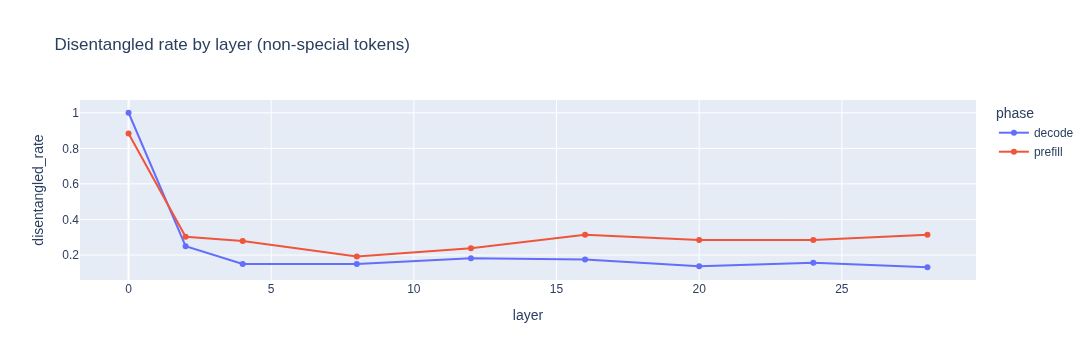

In [20]:
plot_df = summary[summary['is_special_token'] == False]
fig = px.line(plot_df, x='layer', y='disentangled_rate', color='phase', markers=True, title='Disentangled rate by layer (non-special tokens)')
fig.show()

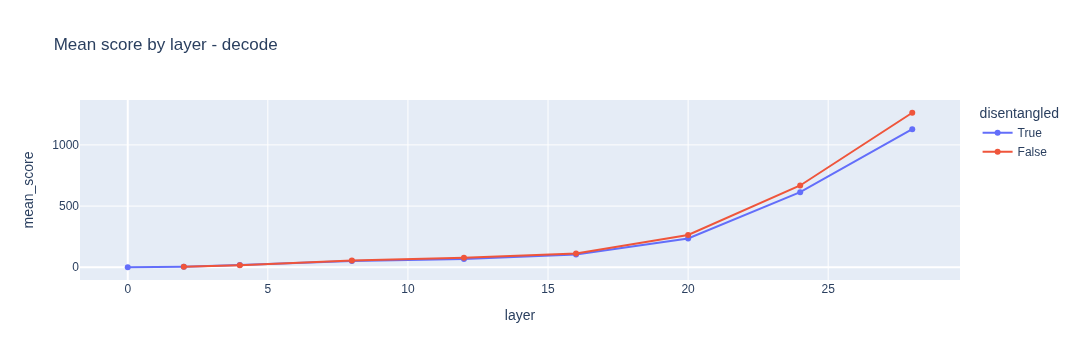

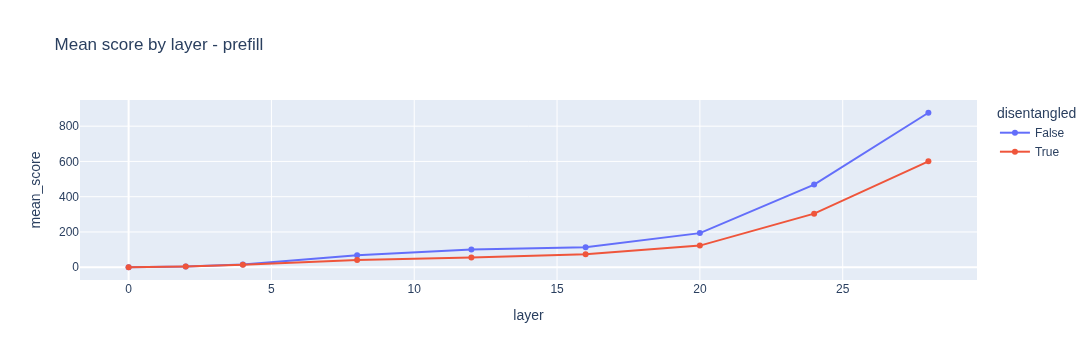

In [21]:
for phase in sorted(df['phase'].unique()):
    sub = df[(df['phase'] == phase) & (~df['is_special_token'])]
    pivot = sub.groupby(['layer', 'disentangled'], as_index=False).agg(mean_score=('score', 'mean'))
    fig = px.line(pivot, x='layer', y='mean_score', color='disentangled', markers=True, title=f'Mean score by layer - {phase}')
    fig.show()

In [22]:
attn_cols = [
    'attn_entropy', 'attn_top1_mass', 'attn_top5_mass', 'attn_recent_8_mass',
    'attn_recent_32_mass', 'attn_bos_mass', 'attn_prev_mass', 'attn_mean_distance'
]
attn_df = df.dropna(subset=['attn_entropy']).copy()
if len(attn_df) == 0:
    print('No attention statistics found.')
else:
    attn_summary = (
        attn_df[~attn_df['is_special_token']]
        .groupby(['phase', 'layer', 'disentangled'], as_index=False)[attn_cols]
        .mean()
    )
    attn_summary.head()

No attention statistics found.


In [23]:
if len(attn_df) > 0:
    metric = 'attn_entropy'
    plot_df = attn_summary.copy()
    plot_df['group'] = plot_df['phase'] + ' | disentangled=' + plot_df['disentangled'].astype(str)
    fig = px.line(plot_df, x='layer', y=metric, color='group', markers=True, title=f'{metric} by layer')
    fig.show()

In [24]:
if len(attn_df) > 0:
    metrics = ['attn_entropy', 'attn_top1_mass', 'attn_recent_32_mass', 'attn_bos_mass', 'attn_mean_distance']
    for metric in metrics:
        plt.figure(figsize=(8, 4))
        for (phase, disentangled), sub in attn_summary.groupby(['phase', 'disentangled']):
            plt.plot(sub['layer'], sub[metric], marker='o', label=f'{phase} | disentangled={disentangled}')
        plt.xlabel('Layer')
        plt.ylabel(metric)
        plt.title(f'{metric} by layer')
        plt.legend()
        plt.tight_layout()
        plt.show()